# Diagonal integration

**Diagonal integration** is the hard case: RNA and ATAC come from **different cells**, with no pairing and no shared cell ids, so a method must align two populations through a shared feature space (for RNA + ATAC, gene-activity scores, computed upstream of this package by e.g. Signac or ArchR). If your RNA and ATAC come from the SAME cells (10x multiome), that is vertical integration - use that tutorial instead.

**Reference dataset:** `D28` (6,408 RNA + 4,606 ATAC cells). The stored results
shipped with these notebooks were produced on it, so every table here
reproduces.

## 1. Install

`pip install multibench-sc` is the whole install: the 1.3 MB wheel ships the
method registry, the stored result tables, the env lockfiles and the reference
metadata. The package alone runs this section, section 3 (`scan`) and sections
4-5. Running methods (section 2, and `run_all` in section 3) additionally
needs their environments - prebuilt linux-64 archives that need no conda
binary - on a **Linux** host. The flag cell decides: with `INSTALL_ENVS =
False` (the default) **Run all** is safe anywhere - nothing is downloaded,
and a run cell on a host without the environments prints one line and
stands in the benchmark host's own results; set it `True` on Colab or a
Linux machine to download the environments in section 2 and run the methods
for real. The install cell pins `numpy` / `pandas` to what the interpreter
already has, so pip never upgrades a host's stack, and defines `tick`, the
recorder behind the timing table at the end of the notebook.

In [1]:
import importlib.metadata, importlib.util, sys, time
_t, TIMES = [time.time()], []                    # "where the time went": tick(label) records the seconds since the previous tick
def tick(label): TIMES.append((label, round(time.time() - _t[0], 1))); _t[0] = time.time()
if importlib.util.find_spec("multibench") is None:
    # pin numpy / pandas to what this interpreter already has, so pip never upgrades the host's stack (Colab pins pandas itself)
    pins = [f"{p}=={importlib.metadata.version(p)}" for p in ("numpy", "pandas") if importlib.util.find_spec(p)]
    !{sys.executable} -m pip -q install "multibench-sc>=0.3" {" ".join(pins)}   # registry, stored tables, env lockfiles and references ship in the wheel - no clone needed
    importlib.invalidate_caches()
    if importlib.util.find_spec("multibench") is None:        # PyPI behind the docs? take the same code straight from GitHub
        !{sys.executable} -m pip -q install "git+https://github.com/DSichang/scMultiBench.git" {" ".join(pins)}
else:
    print("multibench already installed")
tick("install")

multibench already installed


In [2]:
# "Run all" switch. False (the default): nothing is downloaded and no method executes -
# every section runs on any machine, and the run cells stand in the benchmark host's results.
# True: on Colab / any Linux host, download the prebuilt environments for the methods this
# notebook runs (2 envs, at least 1.6 GB to download; no conda needed) and run them here for real.
INSTALL_ENVS = False

In [3]:
%matplotlib inline
import warnings
from pathlib import Path
import anndata
import pandas as pd
from tqdm import TqdmWarning
for _w in (FutureWarning, DeprecationWarning, pd.errors.PerformanceWarning,
           anndata.ImplicitModificationWarning, TqdmWarning):   # library noise only - multibench's own warnings stay visible
    warnings.filterwarnings("ignore", category=_w)
pd.set_option("display.max_colwidth", None)   # never truncate a `reason`
pd.set_option("display.max_columns", None)    # never hide a metric column
pd.set_option("display.width", 200)
import multibench as mtb

DATASET  = "D28"
CATEGORY = "diagonal"
mtb.data.fetch('D28')   # reference data (137 MB) -> mtb.config.DEFAULT.data_path; no-op when present
print("multibench", mtb.__version__)
tick("data fetch")

multibench 0.3.0


## 2. Run the analysis

### Environments - only if you will run methods in this session

Linux; 2 envs, at least 1.6 GB to download (2 of 2 archives measured); `multibench env plan --methods iNMF,online_iNMF,scJoint` prints the per-env sizes. The cell below does nothing
unless `INSTALL_ENVS = True`; then it prints the download the dry run
measures and installs the prebuilt archives for the methods this tutorial
runs (iNMF, online_iNMF, scJoint) under `mtb.config.DEFAULT.envs_dir`
(`~/.cache/multibench/envs` on a host without conda - the archives carry
their own interpreters, and `run` activates a prefix directly, so **no
conda binary is needed**, on Colab included; with conda present the prefix
goes to its envs dir and `conda run` is the fallback: `MULTIBENCH_RUN_MODE`
in the API reference). `env.install` skips anything already present. Other
tiers are one flag away on the command line: `multibench env install
--category diagonal --packed --run` (9 envs, at least 21.6 GB to download (9 of 9 archives measured); `multibench env plan --category diagonal` prints the per-env sizes), or no
flag for the whole benchmark (29 envs; `multibench env plan` totals them).
The archives are linux-64: on macOS / Windows a real install refuses
(`force=True` / `--force` overrides), which is why the cell checks the
platform too. Without the environments, section 3's `scan` and sections 4-5
work as they are.

In [4]:
import sys
if not INSTALL_ENVS:
    print("INSTALL_ENVS is False - no environment is downloaded (sections 3-5 need none)")
elif sys.platform != "linux":
    print("method environments are linux-64 archives - skipped on", sys.platform)
else:
    plan = mtb.env.install(['online_iNMF', 'iNMF', 'scJoint'], category=CATEGORY)              # dry_run=True: the plan, nothing downloaded
    todo = [r for r in plan if not r["exists"]]
    print(f"{len(todo)} of {len(plan)} envs to download, {sum(r['archive_bytes'] or 0 for r in todo) / 1e9:.1f} GB (measured archive sizes)")
    for r in mtb.env.install(['online_iNMF', 'iNMF', 'scJoint'], category=CATEGORY, packed=True, dry_run=False):   # no conda binary needed
        print(f"{r['env']:20s} {r['state']}")
tick("environments")

INSTALL_ENVS is False - no environment is downloaded (sections 3-5 need none)


### One call

One call is the whole pipeline: resolve each method's inputs, run it in its own
environment, load the embeddings, score them with scIB metrics. Here
online_iNMF, iNMF, scJoint. online_iNMF is among the fastest methods here - `run_sec` in the summary is the measured time on our host. The cell first asks `scan` whether
any of these methods has its environment here; where none does (a laptop,
Colab with the flag off) it prints one line and stands in the benchmark
host's own `run_all` outputs for `D28` - `mtb.data.fetch_outputs`
downloads the tree `run_all` wrote there (summary, long table and one
embedding per method) and `mtb.load_batch(..., methods=)` reloads it, so the
statuses, run times and the evaluate cell below are real. Offline, or before
those outputs are published, a second fallback stands in the same methods from the package's own sweep of `D28`
(`load_results(source="rerun")`, the package's re-execution of every wired
method - the paper's own tables are `source="published"`); either way one
printed line says which path was taken and every cell below still renders.

In [5]:
def stored_sweep(dataset, methods=None):
    """The package's own sweep of `dataset` (`load_results(source="rerun")`) as the object
    `run_all` returns, so `.summary` / `.plot()` work on a host that cannot run the methods."""
    long = mtb.load_results(CATEGORY, dataset=dataset, source="rerun", methods=methods)
    recs = [{"method": m, "status": "STORED", "metrics": g.set_index("metric")["value"].to_dict()}
            for m, g in long.groupby("method")]
    return mtb.BatchResult(recs, dataset, CATEGORY)

def stand_in(dataset, methods, stored):
    """What a host without the method environments shows instead of `run_all`'s result: the benchmark
    host's real `run_all` outputs for `dataset` (`mtb.data.fetch_outputs` - embeddings included), else
    the package's stored metric table (`stored_sweep(*stored)`). One line says which."""
    try:
        res = mtb.load_batch(mtb.data.fetch_outputs(dataset), methods=methods)
        print(f"stand-in: the benchmark host's run_all outputs for {dataset} (fetch_outputs) - real embeddings and run times")
        return res
    except Exception as e:                                   # offline, or the outputs are not published yet
        print(f"stand-in: the package's stored metric table ({type(e).__name__} from fetch_outputs: {e})")
        return stored_sweep(*stored)

check = mtb.scan("D28", CATEGORY, methods=['online_iNMF', 'iNMF', 'scJoint'])
if check.env_ok.any():
    res = mtb.run_all("D28", CATEGORY,
                      methods=['online_iNMF', 'iNMF', 'scJoint'],
                      out_dir="/tmp/tutorial_diagonal")
else:
    print("no method environment on this host - the run is skipped; a stand-in computed elsewhere covers it")
    res = stand_in("D28", ['online_iNMF', 'iNMF', 'scJoint'], stored=("D28", ['online_iNMF', 'iNMF', 'scJoint']))
tick("run-or-fetch")
res.summary

[scan] files OK for 3/3 method rows; 3/3 envs installed


[run_all] iNMF (diagonal/D28) ...


[run_all]   -> CHAIN_OK (66.8s) 0.4849


[run_all] online_iNMF (diagonal/D28) ...


[run_all]   -> CHAIN_OK (19.3s) 0.4009


[run_all] scJoint (diagonal/D28) ...


[run_all]   -> CHAIN_OK (76.2s) 0.5871


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,iNMF,CHAIN_OK,66.8,embedding,"[11014, 20]",0,rna_cty.csv+atac_cty.csv,0.9986,file_of_origin,2,0.4849,0.5337,0.4946,0.4832,0.4465,0.9649,0.7940,0.7744,0.6382,None
1,online_iNMF,CHAIN_OK,19.3,embedding,"[11014, 20]",0,rna_cty.csv+atac_cty.csv,0.9980,file_of_origin,2,0.4009,0.4966,0.4666,0.4589,0.4184,0.9479,0.7777,0.7569,0.5604,None
2,scJoint,CHAIN_OK,76.2,embedding,"[11014, 64]",21,rna_cty.csv+atac_cty.csv,0.9993,file_of_origin,2,0.5871,0.6239,0.5349,0.5238,0.5864,0.9904,0.7571,0.8696,0.5319,None


`summary` is sorted by method name, whatever order `methods=` listed;
`emb_shape` is the embedding each method produced and `batch_source` says which
batch vector the batch metrics used; a stand-in from the benchmark host carries
that host's `status` and `run_sec`, one from the stored metric table says
`STORED` in `status` and leaves the run columns empty. 
The scoring step on its own - what `run_all` did per method - is one
`mtb.evaluate` call on the embedding file a method wrote, with the label files
in the order the method stacked its cells (`labels_for` returns them in the
benchmark's stacking order; the record's `labels_used` is what `run_all`
matched). ARI, NMI and iF1 need scIB's Leiden resolution sweep, the slow
part; the sweep's flavor is the `mtb.config.DEFAULT.leiden_flavor` knob
(`"igraph"`, the fast default, or `"leidenalg"`):

In [6]:
m, emb = "online_iNMF", None
if res.out_dir is not None:
    emb = Path(res.out_dir) / f"{m}_{res.dataset}" / "embedding.h5"    # what run_all (and the benchmark host) wrote for it
if emb is None or not emb.is_file():
    print("no embedding on this host (metric-table stand-in) - evaluate runs when a method ran here or fetch_outputs supplied the outputs")
    scores = None
else:
    rec = next(r for r in res.results if r["method"] == m)
    order = [Path(f).stem for f in rec.get("labels_used") or []] or None    # the label files in the order the method stacked its cells
    scores = mtb.evaluate(emb, labels=mtb.labels_for(res.dataset), label_order=order, verbose=False)
tick("evaluate")
scores.T if scores is not None else None

,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI
Value,0.40092,0.496576,0.466586,0.458892,0.41836,0.947932,0.777673,0.756943,0.56041


The result object plots itself in the paper's layout:

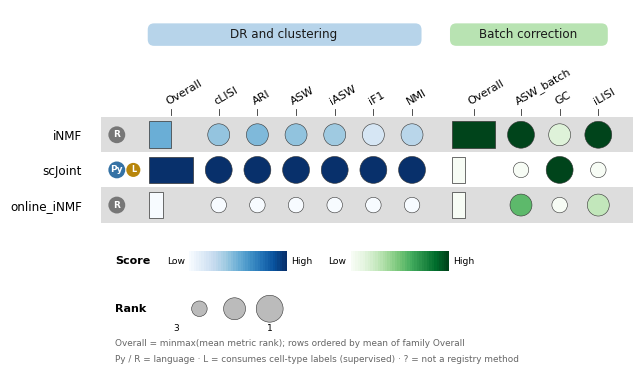

In [7]:
fig = res.plot()
tick("plot")
fig

Each circle carries two encodings: its **size is the method's rank** in
that column (largest = rank 1) and its **colour is the metric's value**, min-max
scaled within the column (darker = higher). Columns are grouped by task family -
blues for DR & clustering, greens for batch correction - and each family is led
by an **Overall** rank column, where bar length and colour carry the same two
encodings.

## 3. Your own data

The same three calls - `scan`, `run_all`, `plot` - on a folder the package has
never seen. A dataset is a folder of flat files named by category:

In [8]:
print(mtb.describe_layout(CATEGORY))

Put your files in  <data_path>/<DATASET_NAME>/ , e.g. ./data/MYDATA/
  (dataset = the folder NAME; data_path = the folder that CONTAINS it)

LAYOUT FOR DIAGONAL:
  rna.h5         <- the RNA cells
  atac.h5        <- the ATAC cells (gene activity); peak.h5 for peaks
  rna_cty.csv AND atac_cty.csv
                 <- ONE LABEL FILE PER MODALITY. The two cell sets are
                    disjoint, so they cannot share a single cty.csv.

  (numbered files live in the SAME flat dir; there is no batch column)

Modality roles and the filenames they resolve to:
    rna              rna.h5      - gene expression
    adt              adt.h5      - surface protein (CITE-seq antibody-derived tags)
    atac             atac.h5     - chromatin accessibility
    atac_gas         atac.h5     - ATAC as GENE-ACTIVITY scores  <-- note: plain atac.h5
    atac_peak        peak.h5     - ATAC as PEAKS                 <-- note: peak.h5, NOT atac.h5
    rna1/rna2/...    rna1.h5, rna2.h5, ... - one file per BAT

Each modality file is HDF5 with three datasets:

| dataset | contents | shape |
|---|---|---|
| `matrix/data` | the matrix, **features x cells** | `(n_features, n_cells)` |
| `matrix/features` | one name per feature | `(n_features,)` |
| `matrix/barcodes` | one id per cell | `(n_cells,)` |

That is the **transpose** of the AnnData convention (`AnnData.X` is cells x
genes); the `mtb.io` writers below handle it, and `scan()` rejects a transposed
file at preflight rather than letting a method fail half an hour in. The label
CSV is a **single column** with one header line (typically `x`) and one label
per cell, in the same order as `matrix/barcodes` of the matching modality file.
For ATAC, check which representation a method wants - gene-activity scores or
peaks - because the wrong one runs to completion and returns a plausible but
wrong embedding. The shipped label files, as `evaluate` will read them - the
dict comes back in the benchmark's **cell-stacking order** (`cty`; `cty1, cty2,
...` numerically; `rna_cty` before `atac_cty`), so
`mtb.evaluate(embedding, labels=mtb.labels_for(DATASET), metrics="all")` scores a
multi-file dataset directly, with each cell's file of origin as its batch.
`metrics=` is the one selection knob: `None` (the default) computes every
applicable metric - the clustering family, plus the batch family whenever a
batch vector exists; `"clustering"` / `"batch"` / `"all"` name a family, and a
list of codes (`["ARI", "NMI"]`) names exactly those (batch metrics need
`batch=` or a multi-file `labels`). A dict you built in any other order must
say so with `label_order=[...]`:

In [9]:
labels = mtb.labels_for(DATASET)            # {stem: path} in cell-stacking order - what the metrics are scored against
print({k: Path(v).name for k, v in labels.items()})
print(*Path(next(iter(labels.values()))).read_text().splitlines()[:4], sep="\n")

{'rna_cty': 'rna_cty.csv', 'atac_cty': 'atac_cty.csv'}
"x"
"CD4 Naive"
"CD4 Naive"
"CD4 TCM"


Writing that layout from AnnData objects, executed here on a synthetic
example - sparse matrices stream without densifying, and the folder passes the
same file gate `scan` applies to the shipped datasets:

In [10]:
import anndata as ad, numpy as np, tempfile, os
rng = np.random.default_rng(0)
genes = [f"gene{i}" for i in range(40)]
rna  = ad.AnnData(X=rng.poisson(1.0, size=(120, 40)).astype(float)); rna.var_names = genes
atac = ad.AnnData(X=rng.poisson(0.5, size=(90, 40)).astype(float));  atac.var_names = genes   # gene-activity scores, DIFFERENT cells
rna.obs["celltype"]  = rng.choice(["T", "B", "NK"], 120)
atac.obs["celltype"] = rng.choice(["T", "B", "NK"], 90)

def write_cty(labels, path):                                  # the label file: one header line ("x"), one label per cell
    pd.Series(np.asarray(labels), name="x").to_csv(path, index=False)

folder = os.path.join(tempfile.mkdtemp(), "MYDIAG"); os.makedirs(folder)
mtb.io.to_canonical(rna,  folder, modality="rna")        # -> rna.h5
mtb.io.to_canonical(atac, folder, modality="atac_gas")   # -> atac_gas.h5 (never a plain atac.h5, which methods read as PEAKS)
write_cty(rna.obs["celltype"],  os.path.join(folder, "rna_cty.csv"))
write_cty(atac.obs["celltype"], os.path.join(folder, "atac_cty.csv"))
print(sorted(os.listdir(folder)))
sc = mtb.scan("MYDIAG", CATEGORY, data_path=os.path.dirname(folder))
print(f"{int(sc.files_ok.sum())} of {len(sc)} method variants pass the file gate (the rest want a peak matrix too)")

['atac_cty.csv', 'atac_gas.h5', 'rna.h5', 'rna_cty.csv']
[scan] files OK for 10/14 method rows; 14/14 envs installed


10 of 14 method variants pass the file gate (the rest want a peak matrix too)


Now a real dataset the package has never seen: a small slice of
`D28` under a new name - a random 60% of the cells capped at 2,000,
and at most 5,000 features per matrix - built with ordinary h5py/pandas code so
the per-file rule (matching files keep the same cell index) is visible. The cap
keeps the copy small enough to write in seconds on Colab (the full peak matrix
of a mosaic dataset is several GB dense).

In [11]:
import os, shutil
import h5py
import numpy as np
import pandas as pd

def subsample_dataset(src_dir, dst_dir, frac=0.6, seed=0, max_cells=2000, max_features=5000):
    """Copy a dataset to a new name, keeping a random slice of it.

    Cells: a random ``frac`` of each file's cells, capped at ``max_cells``.
    Files sharing a cell count get the SAME kept-cell index, so modality files
    and their label CSVs stay aligned - which is exactly the property your own
    export pipeline must preserve. Features: files with more than
    ``max_features`` rows (peak matrices) keep a random subset, so the copy
    stays small and fast to write. The output is the canonical layout:
    matrix/data as features x cells, plus matrix/features and matrix/barcodes.
    """
    rng = np.random.default_rng(seed)
    os.makedirs(dst_dir, exist_ok=True)
    counts, keep = {}, {}
    for fn in sorted(os.listdir(src_dir)):
        p = os.path.join(src_dir, fn)
        if fn.endswith(".h5"):
            with h5py.File(p) as f:
                if "matrix/data" in f:
                    counts[fn] = f["matrix/data"].shape[1]   # features x cells
        elif fn.endswith(".csv"):
            counts[fn] = len(pd.read_csv(p))
    for n in set(counts.values()):
        k = min(max(50, int(n * frac)), max_cells)
        keep[n] = np.sort(rng.choice(n, size=k, replace=False))
    for fn, n in counts.items():
        sp, dp = os.path.join(src_dir, fn), os.path.join(dst_dir, fn)
        idx = keep[n]
        if fn.endswith(".csv"):
            pd.read_csv(sp).iloc[idx].to_csv(dp, index=False)
        else:
            with h5py.File(sp) as f, h5py.File(dp, "w") as g:
                grp = g.create_group("matrix")
                n_feat = f["matrix/data"].shape[0]
                fidx = np.arange(n_feat) if n_feat <= max_features else np.sort(rng.choice(n_feat, size=max_features, replace=False))
                block = f["matrix/data"][fidx, :] if n_feat > max_features else f["matrix/data"][()]   # one fancy index per h5py read
                grp.create_dataset("data", data=np.asarray(block)[:, idx])
                if "matrix/features" in f:
                    grp.create_dataset("features", data=np.asarray(f["matrix/features"])[fidx])
                if "matrix/barcodes" in f:
                    grp.create_dataset("barcodes", data=np.asarray(f["matrix/barcodes"])[idx])
    return dst_dir

`scan` checks two independent gates per method: `files_ok` - the folder
itself (files present, features x cells orientation, one label per cell) - and
`env_ok` - that method's conda environment exists on this machine. `runnable`
is both; `reason` says which failed and how to fix it. The file gate runs
anywhere, so a laptop without a single environment still tells you whether your
layout is right.

In [12]:
DATA_ROOT = "/tmp/mydata"
src = mtb.config.DEFAULT.data_path / "D28"
subsample_dataset(src, f"{DATA_ROOT}/MYDATA_diagonal", frac=0.6)

sc = mtb.scan(f"MYDATA_diagonal", category=CATEGORY, data_path=DATA_ROOT)
print(f"files_ok {int(sc.files_ok.sum())}, env_ok {int(sc.env_ok.sum())}, runnable {int(sc.runnable.sum())} of {len(sc)} method variants")
sc[["method", "modalities", "files_ok", "env_ok", "runnable", "reason"]].head(6)

[scan] files OK for 14/14 method rows; 14/14 envs installed


files_ok 14, env_ok 14, runnable 14 of 14 method variants


,method,modalities,files_ok,env_ok,runnable,reason
0,Conos,rna+atac_gas,True,True,True,
1,GLUE,rna+atac_peak,True,True,True,
2,MultiMAP,rna+atac_peak+atac_gas,True,True,True,
3,Portal,rna+atac_gas,True,True,True,
4,SCALEX,rna+atac_gas,True,True,True,
5,Seurat_v3,rna+atac_peak+atac_gas,True,True,True,


In [13]:
if sc[sc.method.isin(['online_iNMF', 'iNMF', 'scJoint'])].env_ok.any():
    mine = mtb.run_all(f"MYDATA_diagonal", CATEGORY,
                       methods=['online_iNMF', 'iNMF', 'scJoint'],
                       out_dir=f"{DATA_ROOT}/out_diagonal",
                       data_path=DATA_ROOT)
else:
    print("no method environment on this host - the run is skipped; a stand-in computed elsewhere covers it")
    mine = stored_sweep("D28s", ['online_iNMF', 'iNMF', 'scJoint'])   # D28s: the package's own 60% subsample of D28 (the same construction, uncapped)
tick("own data")
mine.summary

[run_all] iNMF (diagonal/MYDATA_diagonal) ...


[run_all]   -> CHAIN_OK (15.3s) 0.2973


[run_all] online_iNMF (diagonal/MYDATA_diagonal) ...


[run_all]   -> FAIL (7.2s) 


[run_all] scJoint (diagonal/MYDATA_diagonal) ...


[run_all]   -> CHAIN_OK (24.9s) 0.1781


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,iNMF,CHAIN_OK,15.3,embedding,"[4000, 20]",0,rna_cty.csv+atac_cty.csv,0.9983,file_of_origin,2.0,0.2973,0.3900,0.4425,0.4501,0.3171,0.9210,0.7818,0.7312,0.8453,None
1,online_iNMF,FAIL,7.2,embedding,None,0,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not scored
2,scJoint,CHAIN_OK,24.9,embedding,"[4000, 64]",21,rna_cty.csv+atac_cty.csv,0.9349,file_of_origin,2.0,0.1781,0.3472,0.4488,0.4460,0.3389,0.9252,0.6330,0.6500,0.2991,None


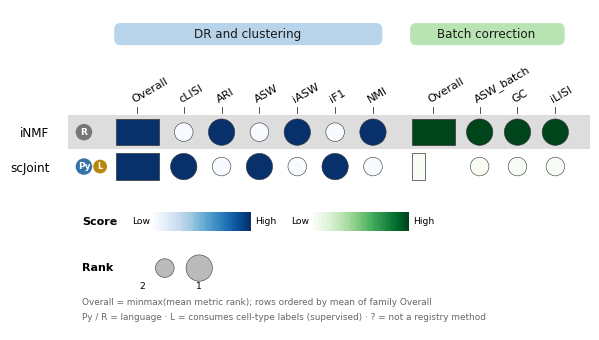

In [14]:
mine.plot()

All three reached CHAIN_OK with all nine metrics on this subsample when we ran them. For your real data the only work is producing the
canonical files - `mtb.io.export_dataset` from an AnnData / MuData, or
`to_canonical` per matrix plus a one-column `x` CSV per label set, as above -
and these same three calls do the rest.

## 4. Reading stored results

Section 2 ran three methods; the package ships the **full sweep** for `D28` -
every wired method at default settings, hours of compute - so the paper's
figures reproduce from stored results in seconds. `load_results` reads them
back as the tidy frame `mtb.plot.bubble` takes, and every row says in its
`source` column which sweep it came from. The paper's table for `D28` holds 14 methods against 12 in the package's sweep, so the default `source="published"` would show 14 - every call in this notebook names its source.

/tmp/ipykernel_2299505/1856492017.py:1: DegenerateRerunWarning: degenerate re-run row(s) - ARI < 0.01 where the published table scored > 0.2: Conos/D28 (rerun-0.2.1 ARI 0.0004 vs published 0.27). The re-run most likely failed silently (a collapsed embedding or a wrong label order), so the row says nothing about the method; drop it before ranking (df[df.method != 'Conos']) or compare with source='published'.
  long = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun")


12 methods, ['rerun']


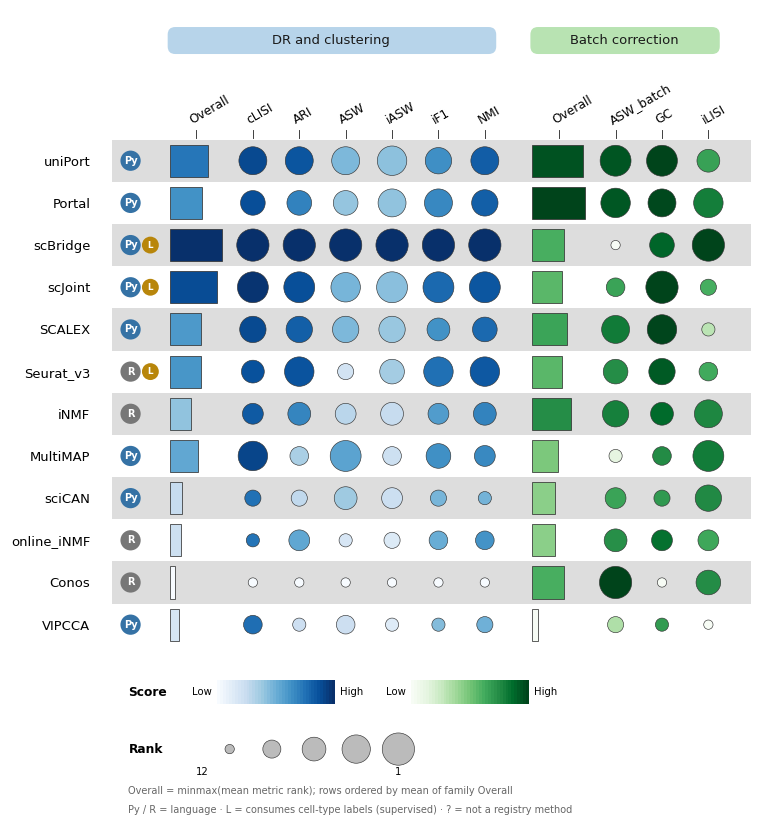

In [15]:
long = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun")
print(long.method.nunique(), "methods,", long.source.unique())
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
tick("stored results")
fig

`run_all(DATASET, CATEGORY, out_dir=...)` without `methods=` writes the
same `summary.csv` and `long.csv` for your own data; `mtb.load_batch(out_dir)`
reads them back (`methods=` keeps a subset, as the stand-in above did). A
single `mtb.evaluate` frame becomes the same seven-column
long frame with `mtb.to_long(metrics, method=..., dataset=..., category=...)`
(`source="user"`), so `pd.concat([long, mine])` plots next to the stored
sweep.

**Across datasets.** A summary needs every method to have results on every
dataset it averages over, or absence and performance blur into the same bar. Two
diagonal datasets therefore ship swept identically - `D28` and `D28s` (a 60% cell
subsample of `D28` under a new name) - and `require_complete=True` keeps only
the methods present on both, so the matrix is complete by construction. Each
bar is the **grand rank**: the min-max scaled mean rank across the datasets,
with length and colour both carrying it, and `Overall` is the same statistic
over the grand ranks. Both metric families appear because both datasets are multi-batch.

/tmp/ipykernel_2299505/1307261061.py:1: DegenerateRerunWarning: degenerate re-run row(s) - ARI < 0.01 where the published table scored > 0.2: Conos/D28 (rerun-0.2.1 ARI 0.0004 vs published 0.27). The re-run most likely failed silently (a collapsed embedding or a wrong label order), so the row says nothing about the method; drop it before ranking (df[df.method != 'Conos']) or compare with source='published'.
  pair = mtb.load_results(CATEGORY, dataset=[DATASET, DATASET + "s"], source="rerun")


{'D28': 12, 'D28s': 12}


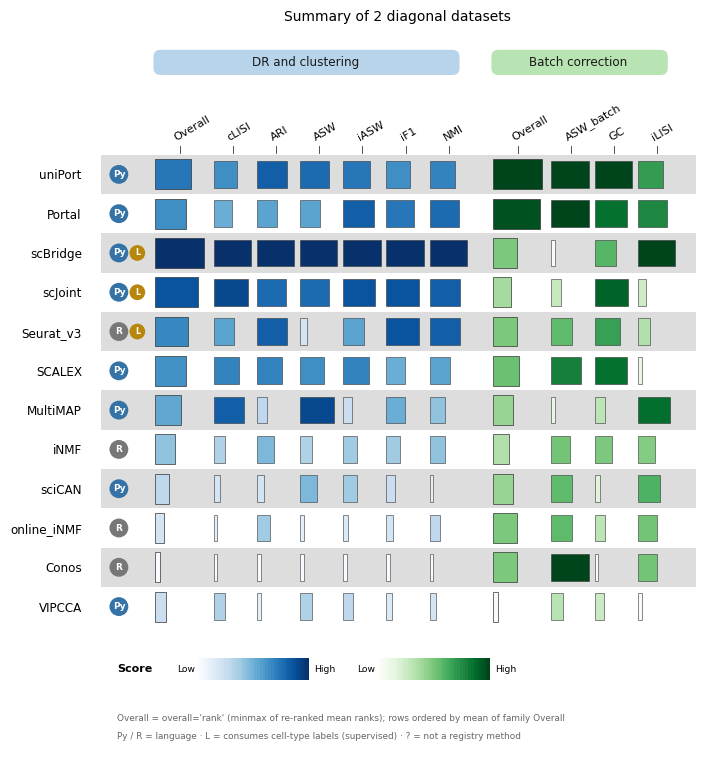

In [16]:
pair = mtb.load_results(CATEGORY, dataset=[DATASET, DATASET + "s"], source="rerun")
print(pair.groupby("dataset").method.nunique().to_dict())
mtb.plot.bubble(pair, aggregate="summary", require_complete=True,
                title=f"Summary of 2 diagonal datasets")

**Published vs re-run.** The paper's own tables (`source="published"`)
and the package's re-runs can differ for a method - methods are stochastic and
the published sweep ran on other hardware - so cite the published numbers and
use the re-runs to check reproducibility; compare ranks, not decimals.
`results_coverage` says what exists for this dataset and where it came from:

In [17]:
cov = mtb.results_coverage(CATEGORY)
cov[cov.dataset == DATASET].groupby("source").method.nunique()

source
published    14
rerun        12
Name: method, dtype: int64

## 5. Reference

### What runs on a dataset, and why not

`scan` inspects a folder and reports every runnable method - and for the rest,
the exact reason (missing file, missing environment, wrong layout). Nothing
executes. From the shell, `multibench scan DATASET --category CATEGORY` prints
the compact table (method, modalities, runnable, files_ok, env_ok,
runtime_tier, reason); `--columns all` or `--format csv|tsv|json` gives every
column - including `command`, the exact shell line `run()` would execute for
every variant whose inputs resolve (the line to paste into a scheduler job;
`multibench run-all ... --dry-run` prints the same table). Below, the rows the
**data** admits (`files_ok`), with the
environment gate next to them: `env_ok` is what this machine has, `env_reason`
the install line for what it lacks, and `runnable` (both gates) stays empty
until the environments exist.

In [18]:
avail = mtb.scan(DATASET, category=CATEGORY)
print(f"files_ok {int(avail.files_ok.sum())}, env_ok {int(avail.env_ok.sum())}, runnable {int(avail.runnable.sum())} of {len(avail)} method variants")
avail[avail.files_ok][["method", "modalities", "env", "env_ok", "env_reason",
                       "output_kind", "needs_labels", "runtime_tier"]]

[scan] files OK for 14/14 method rows; 14/14 envs installed


files_ok 14, env_ok 14, runnable 14 of 14 method variants


,method,modalities,env,env_ok,env_reason,output_kind,needs_labels,runtime_tier
0,Conos,rna+atac_gas,scmb_r,True,,embedding,False,medium
1,GLUE,rna+atac_peak,glue,True,,embedding,False,very_slow
2,MultiMAP,rna+atac_peak+atac_gas,scmb_torch,True,,embedding,False,slow
3,Portal,rna+atac_gas,scmb_torch_v2,True,,embedding,False,medium
4,SCALEX,rna+atac_gas,scmb_torch,True,,embedding,False,slow
5,Seurat_v3,rna+atac_peak+atac_gas,scmb_seurat4b,True,,embedding,True,slow
6,Seurat_v5,rna+atac_peak,scmb_seurat5,True,,embedding,False,very_slow
7,VIPCCA,rna+atac_gas,scmb_vipcca27,True,,embedding,False,medium
8,iNMF,rna+atac_gas,scmb_r,True,,embedding,False,fast
9,online_iNMF,rna+atac_gas,scmb_r,True,,embedding,False,fast


In [19]:
not_ok = avail[~avail.files_ok][["method", "modalities", "files_reason"]]
not_ok.head(5) if len(not_ok) else "(every method's inputs resolve on this dataset)"


"(every method's inputs resolve on this dataset)"

### What each method exposes for tuning

`method_info(m)["supports"]` lists a method's variants with how many
hyperparameters each exposes on its command line; `mtb.params_for(m, CATEGORY,
modalities)` names them, `params={"Method": {"key": value}}` sets them in
`run_all` (`--param METHOD:KEY=VALUE` on the command line; `multibench params
METHOD` prints the same table for every variant). An empty `tunable` is honest: many upstream scripts hardcode their hyperparameters, and this
package never edits upstream code.

In [20]:
rows = [{"method": m, "modalities": "+".join(v["modalities"]) or "(data_dir)",
         "n_tunable": v["n_tunable"], "needs_labels": v["needs_labels"],
         "output_kind": v["output_kind"]}
        for m in sorted(mtb.list_methods(category=CATEGORY))
        for v in mtb.method_info(m)["supports"] if v["category"] == CATEGORY]
pd.DataFrame(rows).sort_values(["n_tunable", "method"], ascending=[False, True]).reset_index(drop=True)

,method,modalities,n_tunable,needs_labels,output_kind
0,scJoint,rna+atac_gas,21,True,embedding
1,scBridge,(data_dir),13,True,embedding
2,uniPort,rna+atac_gas,1,False,embedding
3,Conos,rna+atac_gas,0,False,embedding
4,GLUE,rna+atac_peak,0,False,embedding
5,MultiMAP,rna+atac_peak+atac_gas,0,False,embedding
6,Portal,rna+atac_gas,0,False,embedding
7,SCALEX,rna+atac_gas,0,False,embedding
8,Seurat_v3,rna+atac_peak+atac_gas,0,True,embedding
9,Seurat_v5,rna+atac_peak,0,False,embedding


### What the registry knows about a method, and how to cite it

`method_info` carries the upstream reference, repository and version next to
the run metadata - `availability` says whether a public install can run it
(`'public'`, or `'benchmark-host-only'` for SPIRAL, the one method whose
script is not published), `needs_labels` is the any-variant flag (`supports[i]` has it
per variant), and `verbose=True` adds the long audit notes plus
`verification`, the recorded end-to-end run(s) behind `status='verified'`
(`{dataset, category, status, wall_s, ARI, baseline, verdict, note}`);
`mtb.cite` emits the benchmark entry plus one per method you ran.

In [21]:
info = mtb.method_info("online_iNMF", verbose=True)
{k: info[k] for k in ("id", "env", "availability", "needs_labels", "atac", "notes", "repo_url", "version", "reference", "verification")}

{'id': 'online_iNMF',
 'env': 'scmb_r',
 'availability': 'public',
 'needs_labels': False,
 'atac': 'gene_activity',
 'notes': 'Online (mini-batch) iterative NMF in rliger for scalable diagonal integration of scRNA-seq and scATAC-seq gene activity; R.',
 'repo_url': 'http://htmlpreview.github.io/?https://github.com/welch-lab/liger/blob/master/vignettes/UINMF_vignette.html',
 'version': '2.0.1',
 'reference': {'doi': '10.1038/s41587-021-00867-x',
  'title': 'Iterative single-cell multi-omic integration using online learning',
  'authors': 'Gao C, Liu J, Kriebel AR, Preissl S, Luo C, Castanon R, Sandoval J, Rivkin A, Nery JR, Behrens MM, Ecker JR, Ren B, Welch JD',
  'journal': 'Nature Biotechnology',
  'year': 2021},
 'verification': [{'dataset': 'D28',
   'category': 'diagonal',
   'status': 'CHAIN_OK',
   'wall_s': 99,
   'ARI': 0.3749,
   'baseline': 0.375,
   'verdict': 'OK',
   'note': None}]}

In [22]:
print(mtb.cite(['online_iNMF', 'iNMF', 'scJoint']))   # one line per entry; fmt="bibtex" for the .bib entries

Liu C, Ding S, Kim HJ, Long S, Xiao D, Ghazanfar S, Yang P. Multitask benchmarking of single-cell multimodal omics integration methods. Nature Methods (2025). https://doi.org/10.1038/s41592-025-02856-3
Gao C, Liu J, Kriebel AR, Preissl S, Luo C, Castanon R, Sandoval J, Rivkin A, Nery JR, Behrens MM, Ecker JR, Ren B, Welch JD. Iterative single-cell multi-omic integration using online learning. Nature Biotechnology (2021). https://doi.org/10.1038/s41587-021-00867-x
Welch JD, Kozareva V, Ferreira A, Vanderburg C, Martin C, Macosko EZ. Single-Cell Multi-omic Integration Compares and Contrasts Features of Brain Cell Identity. Cell (2019). https://doi.org/10.1016/j.cell.2019.05.006
Lin Y, Wu TY, Wan S, Yang JYH, Wong WH, Wang YXR. scJoint integrates atlas-scale single-cell RNA-seq and ATAC-seq data with transfer learning. Nature Biotechnology (2022). https://doi.org/10.1038/s41587-021-01161-6


### The metrics

Two families, matching the paper's grouping. All are **higher = better**, on
[0, 1] except ARI (slightly negative at chance level).

| family | metrics | what they measure |
|---|---|---|
| clustering / bio-conservation | `ARI`, `NMI`, `ASW`, `iASW`, `iF1`, `cLISI` | does the embedding separate the annotated cell types? |
| batch correction | `ASW_batch`, `GC`, `iLISI` (+ opt-in `kBET`) | are the batches mixed within each cell type? |

Batch metrics appear only when the dataset has real batches - their absence on a
single-batch dataset is correct, not missing data. `kBET` is computed only when
named (`mtb.evaluate(..., metrics=["ASW_batch", "GC", "iLISI", "kBET"])`)
because it is much slower than the rest.

### Coverage of the paper

`scan()` answers "what runs on this dataset"; this answers how many of the
methods the paper benchmarks for **diagonal** the package wires at all. For each
one it does not, the registry's own record is printed - the categories it
**is** wired for and the tasks (`mtb.list_tasks()` vocabulary) its variants
are registered under; no variant for this category means the paper scored it
here through a task the package does not run.

In [23]:
PAPER = {'vertical': ['totalVI', 'sciPENN', 'Concerto', 'scMSI', 'Matilda', 'MOFA2', 'Multigrate', 'UINMF', 'scMoMaT', 'Seurat_WNN', 'scMM', 'scMDC', 'moETM', 'VIMCCA', 'iPOLNG', 'MIRA', 'UnitedNet', 'scMVP'], 'diagonal': ['scBridge', 'Portal', 'SCALEX', 'VIPCCA', 'Seurat_v3', 'MultiMAP', 'Seurat_v5', 'sciCAN', 'Conos', 'iNMF', 'online_iNMF', 'scJoint', 'GLUE', 'uniPort'], 'mosaic': ['MultiVI', 'scMoMaT', 'StabMap', 'Cobolt', 'UINMF', 'Multigrate', 'SMILE', 'scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN'], 'cross': ['totalVI', 'scMoMaT', 'UnitedNet', 'sciPENN', 'Concerto', 'scMDC', 'StabMap', 'UINMF', 'scMM', 'MOFA2', 'Multigrate', 'PASTE', 'PASTE2', 'SPIRAL', 'GPSA']}

paper = PAPER[CATEGORY]
registry = set(mtb.list_methods())
wired = sorted(m for m in registry
               if any(v["category"] == CATEGORY for v in mtb.method_info(m)["supports"]))
missing = [m for m in paper if m not in wired]
print(f"paper benchmarks {len(paper)} methods for {CATEGORY}; this package wires {len(wired)}")
for m in missing:
    if m in registry:
        info = mtb.method_info(m)
        print(f"  {m}: wired for {', '.join(info['categories'])} only (registered tasks: {', '.join(info['tasks'])})")
    else:
        print(f"  {m}: not in the registry")
if not missing:
    print("full parity with the paper for this category")

paper benchmarks 14 methods for diagonal; this package wires 14
full parity with the paper for this category


## Troubleshooting

| symptom | meaning | fix |
|---|---|---|
| `files_ok` False: input files not found | a required file is absent | the reason names the exact file and lists what IS in the folder |
| `env_ok` False | that method's conda env is not built | the reason carries the one-method `multibench env install ...` command |
| `... looks like cells x features` | matrix stored transposed | re-export with `mtb.io.to_canonical` / `export_dataset` |
| a method FAILs in seconds | wrong input representation or layout | read `res.failures.iloc[0]["error"]` - the full command line and stderr tail are there |
| a method TIMEOUTs | slow, not broken | raise `timeout=`; runtime tiers in `scan` are measured, not guessed |
| `label_order_confidence` low | several label files fit the cell count | check `label_order_candidates` in the record |
| batch metrics scored against the wrong batches | `batch_source="file_of_origin"` is the label-file rule | `res.rescore(batch=my_vector)` re-scores the stored outputs without re-running |


## Next steps

- the other three tutorials: **vertical**, **mosaic**, **cross**
- the hosted interactive explorer: <https://shiny.maths.usyd.edu.au/scMultiBench/> -
  the full benchmark's rankings, browsable without installing anything
- `mtb.recommend(CATEGORY, modalities=[...])` - stored-result ranking with coverage made explicit; methods wired for the category but absent from the chosen `source` appear with `grand_score` NaN rather than vanishing
- `mtb.sweep(...)` - one method over a range of one hyperparameter

## Where the time went

Seconds per stage, as `tick` recorded them (the install line is ~0 on a
kernel that already had the package):

In [24]:
pd.DataFrame(TIMES, columns=["stage", "seconds"])

,stage,seconds
0,install,0.0
1,data fetch,0.6
2,environments,0.0
3,run-or-fetch,264.9
4,evaluate,22.9
5,plot,0.2
6,own data,76.3
7,stored results,0.6
